# IoT anomaly detection: corrected training

The original notebook (`Iot.ipynb`) reports 100% accuracy because some inputs give the answer away.
This notebook shows those problems, removes them, and trains the models the simulator uses.

**What changed**
1. `Type` is no longer an input. It is the label in another form, so it becomes the target of a second, 3-class model.
2. `source_ip`, `source_port` and `timestamp` are dropped (reasons below).
3. Exact duplicate rows are removed before splitting, so the same row can't appear in both train and test.
4. Preprocessing lives in a scikit-learn `Pipeline`, so a single live reading goes through the same steps as training.
5. An Isolation Forest trained on normal traffic only is added, to flag readings unlike anything normal.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from iot_detector import DATA_PATH
from iot_detector.features import DROPPED_COLUMNS, FEATURES, load_dataset

raw = pd.read_csv(DATA_PATH)
print(f"{len(raw)} rows, {raw.duplicated().sum()} exact duplicates")
raw.head()

4108 rows, 106 exact duplicates


,timestamp,source_ip,source_port,duration,destination_bytes,missed_bytes,dst_ip_bytes,Temperature,Humidity,Status,Label,Type
0,1970-01-01 00:00:01,192.168.18.138,58770,691,51,0,197,30.8,55.0,OFF,0,normal
1,1970-01-01 00:00:01,192.168.18.138,58770,609,51,0,197,30.8,55.0,ON,0,normal
2,1970-01-01 00:00:01,192.168.18.138,58770,701,51,51,248,29.9,54.3,ON,0,normal
3,1970-01-01 00:00:01,192.168.18.138,58770,607,51,51,248,29.5,54.1,ON,0,normal
4,1970-01-01 00:00:01,192.168.18.138,58770,608,51,0,197,29.2,54.3,ON,0,normal


## 1. Checking for shortcuts

`Type` maps one-to-one onto `Label`:

In [2]:
pd.crosstab(raw['Type'], raw['Label'])

Label,0,1
Type,,
dos,0,290
mitm,0,1090
normal,2728,0


`source_ip` nearly decides the class by itself: `.138` is only normal, `.162` and `.164` are only MITM. A detector should recognise the attack, not memorise which laptop ran it.

In [3]:
pd.crosstab(raw['source_ip'], raw['Type'])

Type,dos,mitm,normal
source_ip,,,
192.168.18.138,0,0,1020
192.168.18.162,0,207,0
192.168.18.164,0,702,0
192.168.18.166,290,181,1708


`timestamp` has only three distinct values, and attacks sit in contiguous blocks of rows:

In [4]:
print("distinct timestamps:", raw['timestamp'].nunique())
raw.reset_index().groupby('Type')['index'].agg(['min', 'max'])

distinct timestamps: 3


,min,max
Type,,
dos,3242,3531
mitm,1193,2282
normal,0,4107


Temperature and humidity also differ by class. The attacks were recorded while the room was cooler and drier. This is probably a coincidence of timing, not something the attack causes. The features stay in, but the simulator's *synthetic climate* mode tests exactly this weakness.

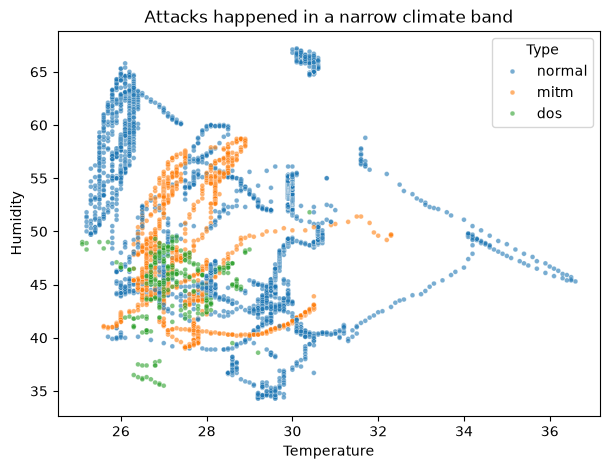

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=raw, x='Temperature', y='Humidity', hue='Type', s=12, alpha=0.6, ax=ax)
ax.set_title('Attacks happened in a narrow climate band');

## 2. How much the shortcuts inflated the score

Same Random Forest and split, with and without the leaky columns:

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df = load_dataset(DATA_PATH)

def score(columns):
    X = pd.get_dummies(df[columns], drop_first=True)
    X_tr, X_te, y_tr, y_te = train_test_split(X, df['Label'], test_size=0.3, random_state=42, stratify=df['Type'])
    return RandomForestClassifier(random_state=42, class_weight='balanced').fit(X_tr, y_tr).score(X_te, y_te)

leaky = FEATURES + ['Type', 'source_ip', 'source_port']
print(f"with Type/source_ip/source_port: {score(leaky):.4f}")
print(f"Type only                       : {score(['Type']):.4f}")
print(f"source_ip only                  : {score(['source_ip']):.4f}")
print(f"corrected features              : {score(FEATURES):.4f}")
print()
for col, why in DROPPED_COLUMNS.items():
    print(f"dropped {col:12s} {why}")

with Type/source_ip/source_port: 1.0000
Type only                       : 1.0000


source_ip only                  : 0.8818


corrected features              : 0.9659

dropped Type         Is the label written another way (normal <=> Label 0). Now a target, not a feature.
dropped source_ip    Shortcut: .138 is always normal, .162/.164 are always MITM.
dropped source_port  Connection identifier, not a device property; attacks use a subset of ports.
dropped timestamp    Only 3 distinct values, carries no information.


## 3. Comparing models on the corrected features

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from iot_detector.features import build_preprocessor

candidates = {
    'Logistic Regression': [('scale', StandardScaler()), ('model', LogisticRegression(class_weight='balanced', max_iter=1000))],
    'Decision Tree': [('model', DecisionTreeClassifier(class_weight='balanced', random_state=42))],
    'Random Forest': [('model', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42))],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, steps in candidates.items():
    pipe = Pipeline([('prep', build_preprocessor())] + steps)
    f1 = cross_val_score(pipe, df[FEATURES], df['Label'], cv=cv, scoring='f1')
    print(f"{name:20s} F1 {f1.mean():.4f} ± {f1.std():.4f}")

Logistic Regression  F1 0.7657 ± 0.0153
Decision Tree        F1 0.9224 ± 0.0143


Random Forest        F1 0.9543 ± 0.0122


## 4. Train and save the simulator's models

`train_all` trains the binary and 3-class Random Forests plus the Isolation Forest. It saves them to `models/`, along with `metadata.json` and `reference.csv` (the rows the simulator draws from).

In [8]:
from iot_detector.train import train_all

meta = train_all()

Trained on 2801 rows, tested on 1201 (after removing duplicates).
binary       accuracy=0.9659  macro F1=0.9624
attack_type  accuracy=0.9525  macro F1=0.9347
novelty      accuracy=0.7361  macro F1=0.6104
binary 5-fold CV F1: 0.9498
Saved models to C:\Users\Awarri\Desktop\ai-agent\iot_dectector\AI-DRIVEN-ANOMALY-DETECTION-SYSTEM-FOR-IOT\models


,accuracy,macro F1
binary,0.9659,0.9624
attack_type,0.9525,0.9347
novelty,0.7361,0.6104


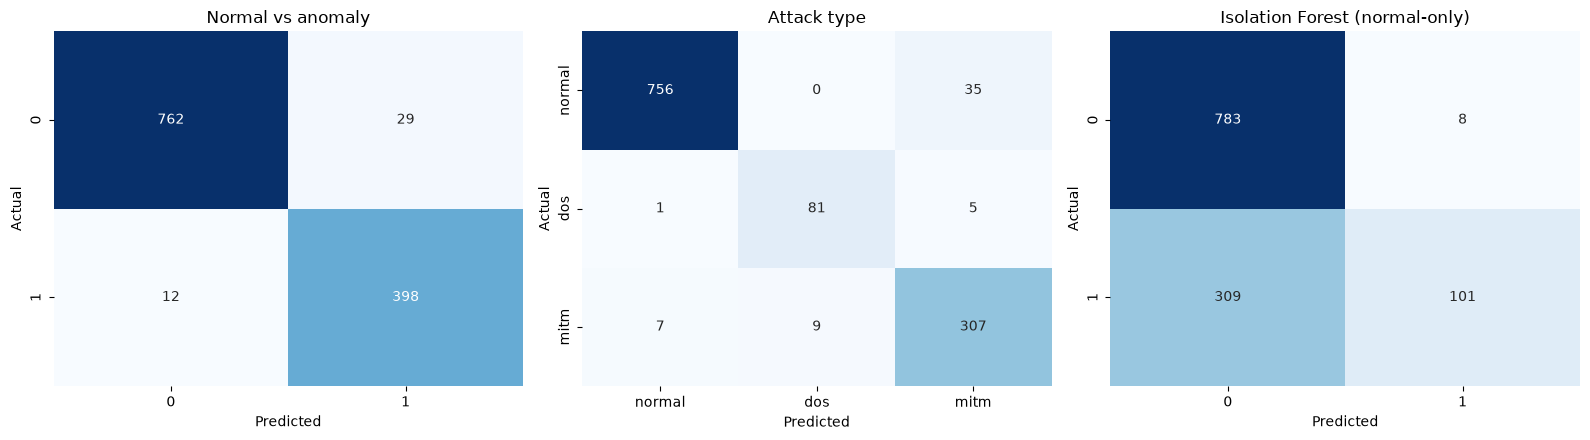

In [9]:
m = meta['metrics']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (key, title) in zip(axes, [('binary', 'Normal vs anomaly'), ('attack_type', 'Attack type'), ('novelty', 'Isolation Forest (normal-only)')]):
    labels = m[key]['labels']
    sns.heatmap(m[key]['confusion_matrix'], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set(title=title, xlabel='Predicted', ylabel='Actual')
fig.tight_layout()

pd.DataFrame({k: {'accuracy': m[k]['report']['accuracy'], 'macro F1': m[k]['report']['macro avg']['f1-score']}
              for k in ('binary', 'attack_type', 'novelty')}).T.round(4)

The Isolation Forest misses most known attacks. That's expected: it only knows what normal looks like, and MITM traffic looks a lot like normal. Its job in the simulator is to catch readings the supervised models have never seen.

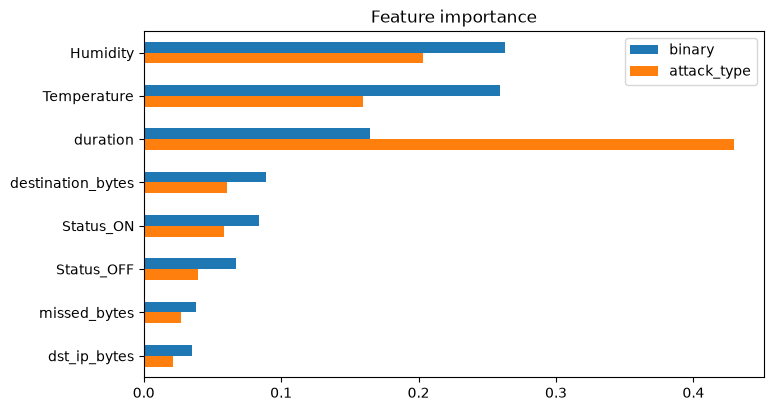

In [10]:
imp = pd.DataFrame(meta['feature_importance']).fillna(0)
imp.plot.barh(figsize=(8, 4.5), title='Feature importance').invert_yaxis()

Temperature and humidity are the top two features for the binary model, which confirms the climate shortcut from section 1. More data recorded with attacks at different times of day would fix this properly.